# Data Partitioning Visualization
## Chronological Train/Test Split for LSTM Modeling

This notebook generates publication-ready timeline figures showing the **chronological data partitioning** strategy used for LSTM time-series modeling across three indices:

| Index | Partitioning | Rationale |
|-------|-------------|----------|
| **Green Index** | 64 / 16 / 20 (Train / Validation / Test) | Environmental data requires a validation set for hyperparameter tuning |
| **Hazard Index** | 80 / 20 (Train / Test) | Maximizes historical learning window for disaster event patterns |
| **Calamity Risk Likelihood** | 80 / 20 (Train / Test) | Same rationale as Hazard Index — disaster event patterns |

In [1]:
# Cell 1: Imports and Configuration

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from pathlib import Path

# ── Shared styling ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 200,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# ── Shared colour palette ──
C_TRAIN = '#2471A3'   # Steel blue  (Training)
C_TEST  = '#E74C3C'   # Coral red   (Testing)
C_VAL   = '#F39C12'   # Warm amber  (Validation)
C_BG    = '#FAFAFA'   # Near-white background
C_EDGE  = '#2C3E50'   # Dark slate  (bar edges)
C_TEXT  = '#1B2631'   # Very dark   (text)

# ── Colour palette for time-series plots ──
C_TRAIN_BG  = '#d5f5e3'  # Light green (training region)
C_TEST_BG   = '#fcf3cf'  # Light yellow-green (test region)
C_LINE      = '#1a5276'  # Dark teal line
C_BOUNDARY  = '#E74C3C'  # Red holdout boundary

# ── LSTM parameters matching the notebooks ──
SEQ_LENGTH  = 6     # 6-month lookback window
TRAIN_SPLIT = 0.80  # 80% train, 20% test

print('Configuration loaded.')

Configuration loaded.


---
## Chronological 80/20 Data Partitioning Sequence for Hazard Index and Calamity Risk Likelihood LSTM Modeling

Both the **Hazard Index** and **Calamity Risk Likelihood** LSTM models use a simple chronological **80 / 20** split:

- **Training Set (80 %)** — earliest sequences, used to learn temporal patterns of multi-hazard events.
- **Testing Set (20 %)** — most recent sequences, held out for final evaluation.

This strategy maximizes the historical learning window, which is critical for disaster event data where long-term temporal context drives prediction quality.

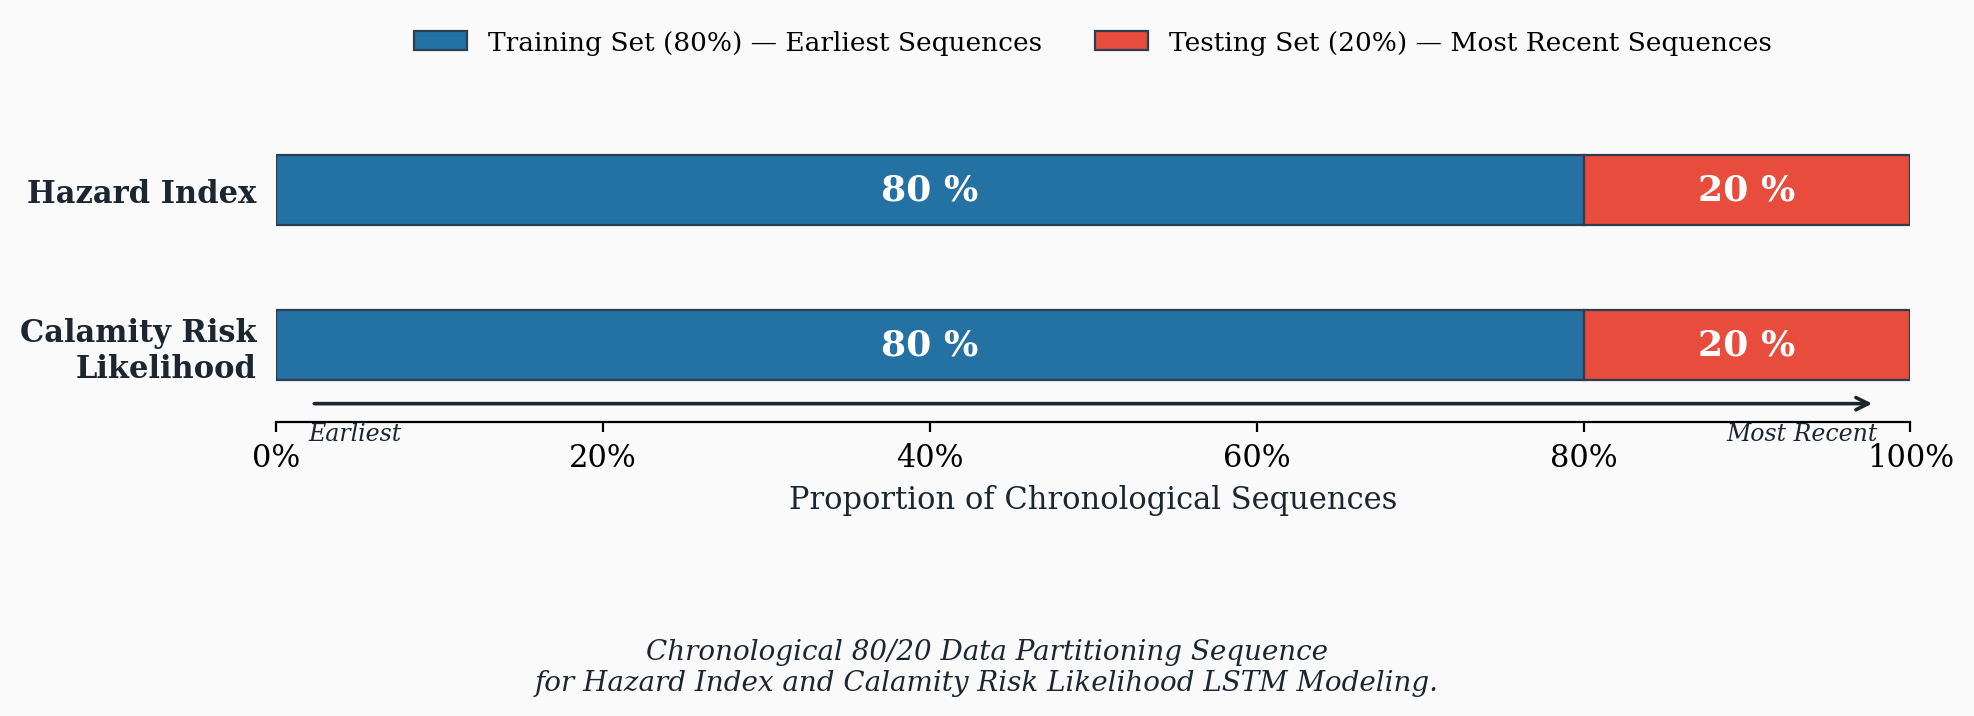


Figure saved → fig_80_20_partitioning_hazard_crl.png


In [2]:
# Cell 2: Hazard Index & CRL — 80/20 Data Partitioning Figure

# ── data ──
indices = ['Hazard Index', 'Calamity Risk\nLikelihood']
train_frac = 0.80
test_frac  = 0.20

bar_height = 0.45       # thickness of each bar
y_positions = [1, 0]    # two bars, vertically stacked

# ── figure ──
fig, ax = plt.subplots(figsize=(10, 3.0))
fig.patch.set_facecolor(C_BG)
ax.set_facecolor(C_BG)

for i, (label, y) in enumerate(zip(indices, y_positions)):
    # Training block (left 80 %)
    ax.barh(y, train_frac, height=bar_height, left=0,
            color=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8,
            label='Training Set (80%) — Earliest Sequences' if i == 0 else '')
    # Testing block (right 20 %)
    ax.barh(y, test_frac, height=bar_height, left=train_frac,
            color=C_TEST, edgecolor=C_EDGE, linewidth=0.8,
            label='Testing Set (20%) — Most Recent Sequences' if i == 0 else '')

    # ── percentage labels inside bars ──
    ax.text(train_frac / 2, y, '80 %', ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')
    ax.text(train_frac + test_frac / 2, y, '20 %', ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

# ── axis styling ──
ax.set_yticks(y_positions)
ax.set_yticklabels(indices, fontsize=11, fontweight='bold', color=C_TEXT)
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 1.6)
ax.set_xlabel('Proportion of Chronological Sequences', fontsize=11, color=C_TEXT)

# x-axis as percentage
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.xaxis.set_major_locator(mticker.MultipleLocator(0.20))

# remove top & right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(left=False)

# ── legend ──
legend_patches = [
    mpatches.Patch(facecolor=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8,
                   label='Training Set (80%) — Earliest Sequences'),
    mpatches.Patch(facecolor=C_TEST,  edgecolor=C_EDGE, linewidth=0.8,
                   label='Testing Set (20%) — Most Recent Sequences'),
]
ax.legend(handles=legend_patches, loc='upper center',
          bbox_to_anchor=(0.5, 1.28), ncol=2, frameon=False,
          fontsize=9.5, handlelength=2.0)

# ── directional arrow below the bar (Earliest → Most Recent) ──
arrow_y = -0.38
ax.annotate('', xy=(0.98, arrow_y), xytext=(0.02, arrow_y),
            arrowprops=dict(arrowstyle='->', color=C_TEXT, lw=1.3),
            annotation_clip=False)
ax.text(0.02, arrow_y - 0.12, 'Earliest', fontsize=8.5, color=C_TEXT,
        ha='left', va='top', fontstyle='italic')
ax.text(0.98, arrow_y - 0.12, 'Most Recent', fontsize=8.5, color=C_TEXT,
        ha='right', va='top', fontstyle='italic')

# ── caption ──
fig.text(0.5, -0.15,
         'Chronological 80/20 Data Partitioning Sequence\n'
         'for Hazard Index and Calamity Risk Likelihood LSTM Modeling.',
         ha='center', va='top', fontsize=10, fontstyle='italic', color=C_TEXT)

plt.tight_layout()
plt.savefig('fig_80_20_partitioning_hazard_crl.png',
            bbox_inches='tight', facecolor=C_BG)
plt.show()

print('\nFigure saved → fig_80_20_partitioning_hazard_crl.png')

---
## Chronological 64/16/20 Data Partitioning Sequence for Green Index LSTM Modeling

The **Green Index** LSTM model uses a three-way chronological split:

- **Training Set (64 %)** — earliest sequences.
- **Validation Set (16 %)** — used for hyperparameter tuning and early-stopping.
- **Testing Set (20 %)** — most recent sequences, held out for final evaluation.

Environmental data (NDVI-based) exhibits slower temporal dynamics, making a dedicated validation partition essential for robust hyperparameter selection without data leakage.

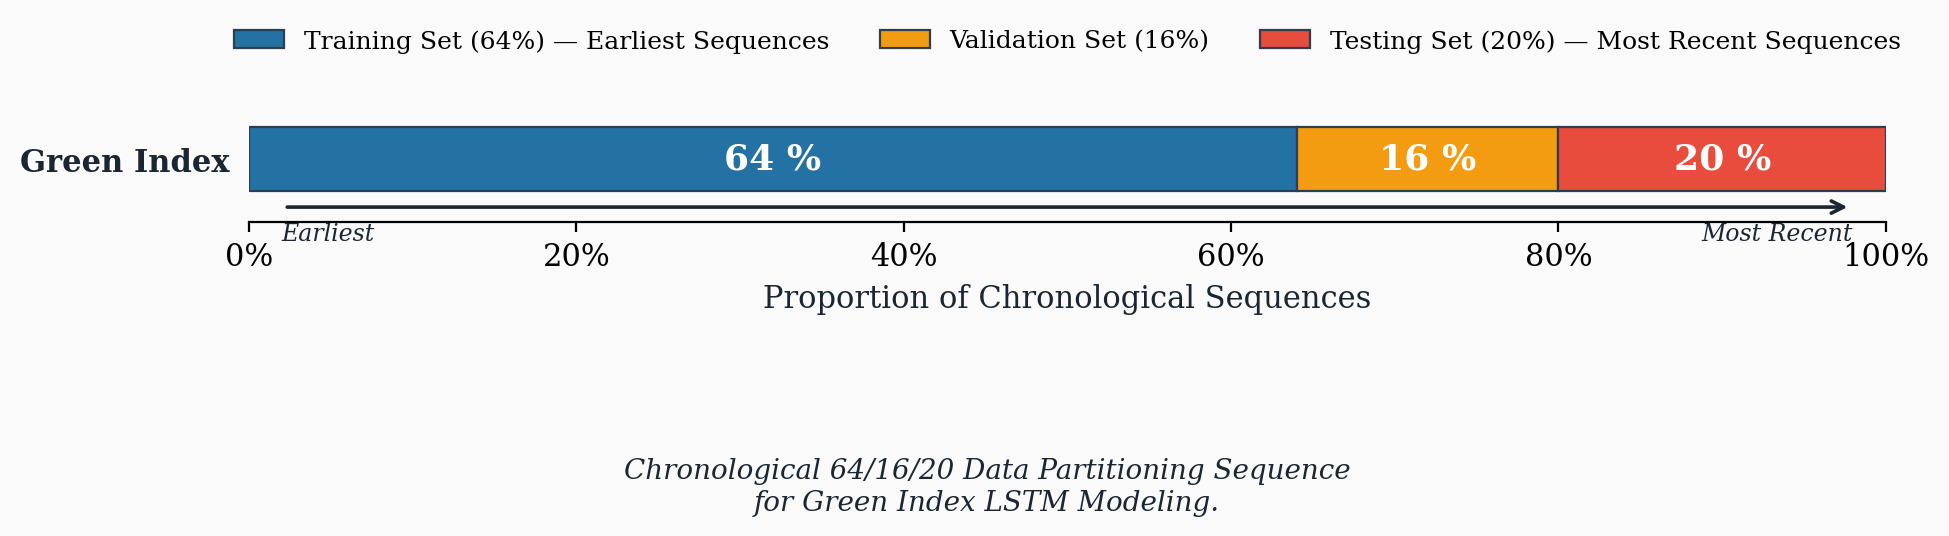


Figure saved → fig_64_16_20_partitioning_green_index.png


In [3]:
# Cell 3: Green Index — 64/16/20 Data Partitioning Figure

# ── data ──
train_frac_gi = 0.64
val_frac_gi   = 0.16
test_frac_gi  = 0.20

bar_height_gi = 0.50

# ── figure ──
fig2, ax2 = plt.subplots(figsize=(10, 2.2))
fig2.patch.set_facecolor(C_BG)
ax2.set_facecolor(C_BG)

y_gi = 0  # single bar

# blocks left → right in chronological order
ax2.barh(y_gi, train_frac_gi, height=bar_height_gi, left=0,
         color=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8)
ax2.barh(y_gi, val_frac_gi,   height=bar_height_gi, left=train_frac_gi,
         color=C_VAL,   edgecolor=C_EDGE, linewidth=0.8)
ax2.barh(y_gi, test_frac_gi,  height=bar_height_gi, left=train_frac_gi + val_frac_gi,
         color=C_TEST,  edgecolor=C_EDGE, linewidth=0.8)

# ── percentage labels ──
ax2.text(train_frac_gi / 2, y_gi, '64 %', ha='center', va='center',
         fontsize=13, fontweight='bold', color='white')
ax2.text(train_frac_gi + val_frac_gi / 2, y_gi, '16 %', ha='center', va='center',
         fontsize=13, fontweight='bold', color='white')
ax2.text(train_frac_gi + val_frac_gi + test_frac_gi / 2, y_gi, '20 %',
         ha='center', va='center', fontsize=13, fontweight='bold', color='white')

# ── axis styling ──
ax2.set_yticks([y_gi])
ax2.set_yticklabels(['Green Index'], fontsize=11, fontweight='bold', color=C_TEXT)
ax2.set_xlim(0, 1)
ax2.set_ylim(-0.5, 0.7)
ax2.set_xlabel('Proportion of Chronological Sequences', fontsize=11, color=C_TEXT)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax2.xaxis.set_major_locator(mticker.MultipleLocator(0.20))

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

# ── legend ──
legend_patches_gi = [
    mpatches.Patch(facecolor=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8,
                   label='Training Set (64%) — Earliest Sequences'),
    mpatches.Patch(facecolor=C_VAL,   edgecolor=C_EDGE, linewidth=0.8,
                   label='Validation Set (16%)'),
    mpatches.Patch(facecolor=C_TEST,  edgecolor=C_EDGE, linewidth=0.8,
                   label='Testing Set (20%) — Most Recent Sequences'),
]
ax2.legend(handles=legend_patches_gi, loc='upper center',
           bbox_to_anchor=(0.5, 1.42), ncol=3, frameon=False,
           fontsize=9, handlelength=2.0)

# ── directional arrow ──
arrow_y2 = -0.38
ax2.annotate('', xy=(0.98, arrow_y2), xytext=(0.02, arrow_y2),
             arrowprops=dict(arrowstyle='->', color=C_TEXT, lw=1.3),
             annotation_clip=False)
ax2.text(0.02, arrow_y2 - 0.12, 'Earliest', fontsize=8.5, color=C_TEXT,
         ha='left', va='top', fontstyle='italic')
ax2.text(0.98, arrow_y2 - 0.12, 'Most Recent', fontsize=8.5, color=C_TEXT,
         ha='right', va='top', fontstyle='italic')

# ── caption ──
fig2.text(0.5, -0.25,
          'Chronological 64/16/20 Data Partitioning Sequence\n'
          'for Green Index LSTM Modeling.',
          ha='center', va='top', fontsize=10, fontstyle='italic', color=C_TEXT)

plt.tight_layout()
plt.savefig('fig_64_16_20_partitioning_green_index.png',
            bbox_inches='tight', facecolor=C_BG)
plt.show()

print('\nFigure saved → fig_64_16_20_partitioning_green_index.png')

---
## Combined Data Partitioning — All Three Indices

A single composite figure showing the data partitioning for all three indices side-by-side for quick comparison during the defense presentation.

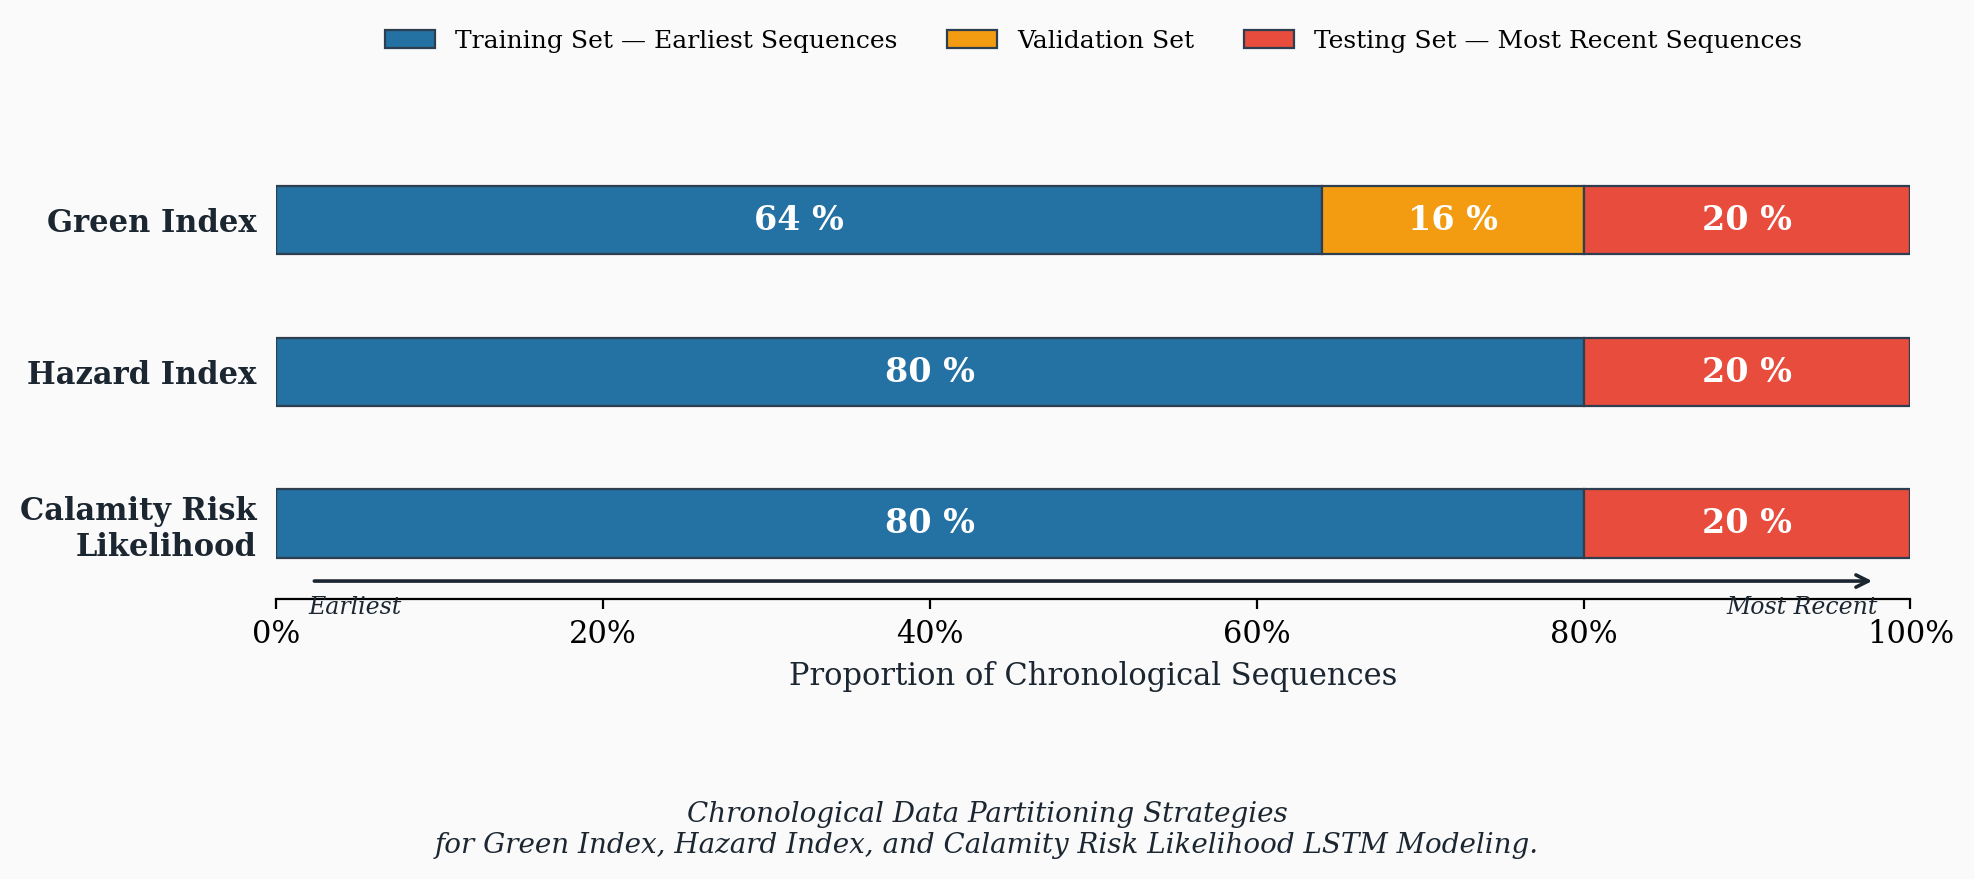


Figure saved → fig_all_partitioning_combined.png


In [4]:
# Cell 4: Combined Partitioning Figure (all 3 indices)

indices_all = ['Green Index', 'Hazard Index', 'Calamity Risk\nLikelihood']
y_all = [2, 1, 0]
bar_h = 0.45

fig3, ax3 = plt.subplots(figsize=(10, 3.8))
fig3.patch.set_facecolor(C_BG)
ax3.set_facecolor(C_BG)

# ── Green Index (64 / 16 / 20) ──
ax3.barh(y_all[0], train_frac_gi, height=bar_h, left=0,
         color=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8)
ax3.barh(y_all[0], val_frac_gi,   height=bar_h, left=train_frac_gi,
         color=C_VAL,   edgecolor=C_EDGE, linewidth=0.8)
ax3.barh(y_all[0], test_frac_gi,  height=bar_h, left=train_frac_gi + val_frac_gi,
         color=C_TEST,  edgecolor=C_EDGE, linewidth=0.8)

ax3.text(train_frac_gi / 2, y_all[0], '64 %', ha='center', va='center',
         fontsize=12, fontweight='bold', color='white')
ax3.text(train_frac_gi + val_frac_gi / 2, y_all[0], '16 %', ha='center', va='center',
         fontsize=12, fontweight='bold', color='white')
ax3.text(train_frac_gi + val_frac_gi + test_frac_gi / 2, y_all[0], '20 %',
         ha='center', va='center', fontsize=12, fontweight='bold', color='white')

# ── Hazard Index & CRL (80 / 20) ──
for y_pos in y_all[1:]:
    ax3.barh(y_pos, train_frac, height=bar_h, left=0,
             color=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8)
    ax3.barh(y_pos, test_frac,  height=bar_h, left=train_frac,
             color=C_TEST,  edgecolor=C_EDGE, linewidth=0.8)

    ax3.text(train_frac / 2, y_pos, '80 %', ha='center', va='center',
             fontsize=12, fontweight='bold', color='white')
    ax3.text(train_frac + test_frac / 2, y_pos, '20 %', ha='center', va='center',
             fontsize=12, fontweight='bold', color='white')

# ── axis styling ──
ax3.set_yticks(y_all)
ax3.set_yticklabels(indices_all, fontsize=11, fontweight='bold', color=C_TEXT)
ax3.set_xlim(0, 1)
ax3.set_ylim(-0.5, 2.7)
ax3.set_xlabel('Proportion of Chronological Sequences', fontsize=11, color=C_TEXT)
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax3.xaxis.set_major_locator(mticker.MultipleLocator(0.20))

ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)
ax3.tick_params(left=False)

# ── legend ──
legend_patches_all = [
    mpatches.Patch(facecolor=C_TRAIN, edgecolor=C_EDGE, linewidth=0.8,
                   label='Training Set — Earliest Sequences'),
    mpatches.Patch(facecolor=C_VAL,   edgecolor=C_EDGE, linewidth=0.8,
                   label='Validation Set'),
    mpatches.Patch(facecolor=C_TEST,  edgecolor=C_EDGE, linewidth=0.8,
                   label='Testing Set — Most Recent Sequences'),
]
ax3.legend(handles=legend_patches_all, loc='upper center',
           bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=False,
           fontsize=9, handlelength=2.0)

# ── directional arrow ──
arrow_y3 = -0.38
ax3.annotate('', xy=(0.98, arrow_y3), xytext=(0.02, arrow_y3),
             arrowprops=dict(arrowstyle='->', color=C_TEXT, lw=1.3),
             annotation_clip=False)
ax3.text(0.02, arrow_y3 - 0.10, 'Earliest', fontsize=8.5, color=C_TEXT,
         ha='left', va='top', fontstyle='italic')
ax3.text(0.98, arrow_y3 - 0.10, 'Most Recent', fontsize=8.5, color=C_TEXT,
         ha='right', va='top', fontstyle='italic')

# ── caption ──
fig3.text(0.5, -0.10,
          'Chronological Data Partitioning Strategies\n'
          'for Green Index, Hazard Index, and Calamity Risk Likelihood LSTM Modeling.',
          ha='center', va='top', fontsize=10, fontstyle='italic', color=C_TEXT)

plt.tight_layout()
plt.savefig('fig_all_partitioning_combined.png',
            bbox_inches='tight', facecolor=C_BG)
plt.show()

print('\nFigure saved → fig_all_partitioning_combined.png')

---
## Chronological Time-Series Split Visualizations

The following cells produce **time-series line plots** (similar to the Green Index split figure) for both **Hazard Index** and **Calamity Risk Likelihood**, showing:

- The city-mean index value over each month (May 2020 – Dec 2025)
- Color-shaded **Training** (green) and **Test / holdout** (yellow) regions
- A red dashed **holdout boundary** line at the 80 % chronological cut-off
- Annotations with date ranges and sequence counts

In [5]:
# Cell 5: Load training data for time-series plots

BASE_PATH = Path('.')  # notebook is in the Hazard directory
df = pd.read_csv(BASE_PATH / 'lstm_training_data.csv', parse_dates=['date'])

# Number of unique months and barangays
unique_dates = sorted(df['date'].unique())
n_months     = len(unique_dates)
n_barangays  = df['barangay'].nunique()

# Sequences per barangay  (total months - lookback window)
n_seq_per_brgy = n_months - SEQ_LENGTH
n_total_seq    = n_seq_per_brgy * n_barangays
n_train_seq    = int(n_seq_per_brgy * TRAIN_SPLIT) * n_barangays
n_test_seq     = n_total_seq - n_train_seq

# Holdout boundary: last month used as a TRAINING target
n_train_months = int(n_seq_per_brgy * TRAIN_SPLIT)  # per-barangay
# Target indices run from SEQ_LENGTH .. n_months-1  (0-indexed)
# The first target is at index SEQ_LENGTH  (month SEQ_LENGTH+1)
# The last training target is at index SEQ_LENGTH + n_train_months - 1
last_train_target_idx = SEQ_LENGTH + n_train_months - 1
first_test_target_idx = last_train_target_idx + 1

holdout_date = unique_dates[first_test_target_idx]

# Date ranges for annotations
train_start = unique_dates[0]
train_end   = unique_dates[last_train_target_idx]
test_start  = holdout_date
test_end    = unique_dates[-1]

# City-mean series
monthly_hi  = df.groupby('date')['hazard_index'].mean()
monthly_crl = df.groupby('date')['calamity_risk_likelihood'].mean()

print(f'Months: {n_months}  |  Barangays: {n_barangays}')
print(f'Sequences per barangay: {n_seq_per_brgy}')
print(f'Total sequences: {n_total_seq}  |  Train: {n_train_seq}  |  Test: {n_test_seq}')
print(f'Holdout boundary: {pd.Timestamp(holdout_date).strftime("%Y-%m")}')
print(f'Training period : {pd.Timestamp(train_start).strftime("%Y-%m")} → {pd.Timestamp(train_end).strftime("%Y-%m")}')
print(f'Test period     : {pd.Timestamp(test_start).strftime("%Y-%m")} → {pd.Timestamp(test_end).strftime("%Y-%m")}')

Months: 68  |  Barangays: 18
Sequences per barangay: 62
Total sequences: 1116  |  Train: 882  |  Test: 234
Holdout boundary: 2024-12
Training period : 2020-05 → 2024-11
Test period     : 2024-12 → 2025-12


C:\Users\arbut\AppData\Local\Temp\ipykernel_24872\3229392151.py:65: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


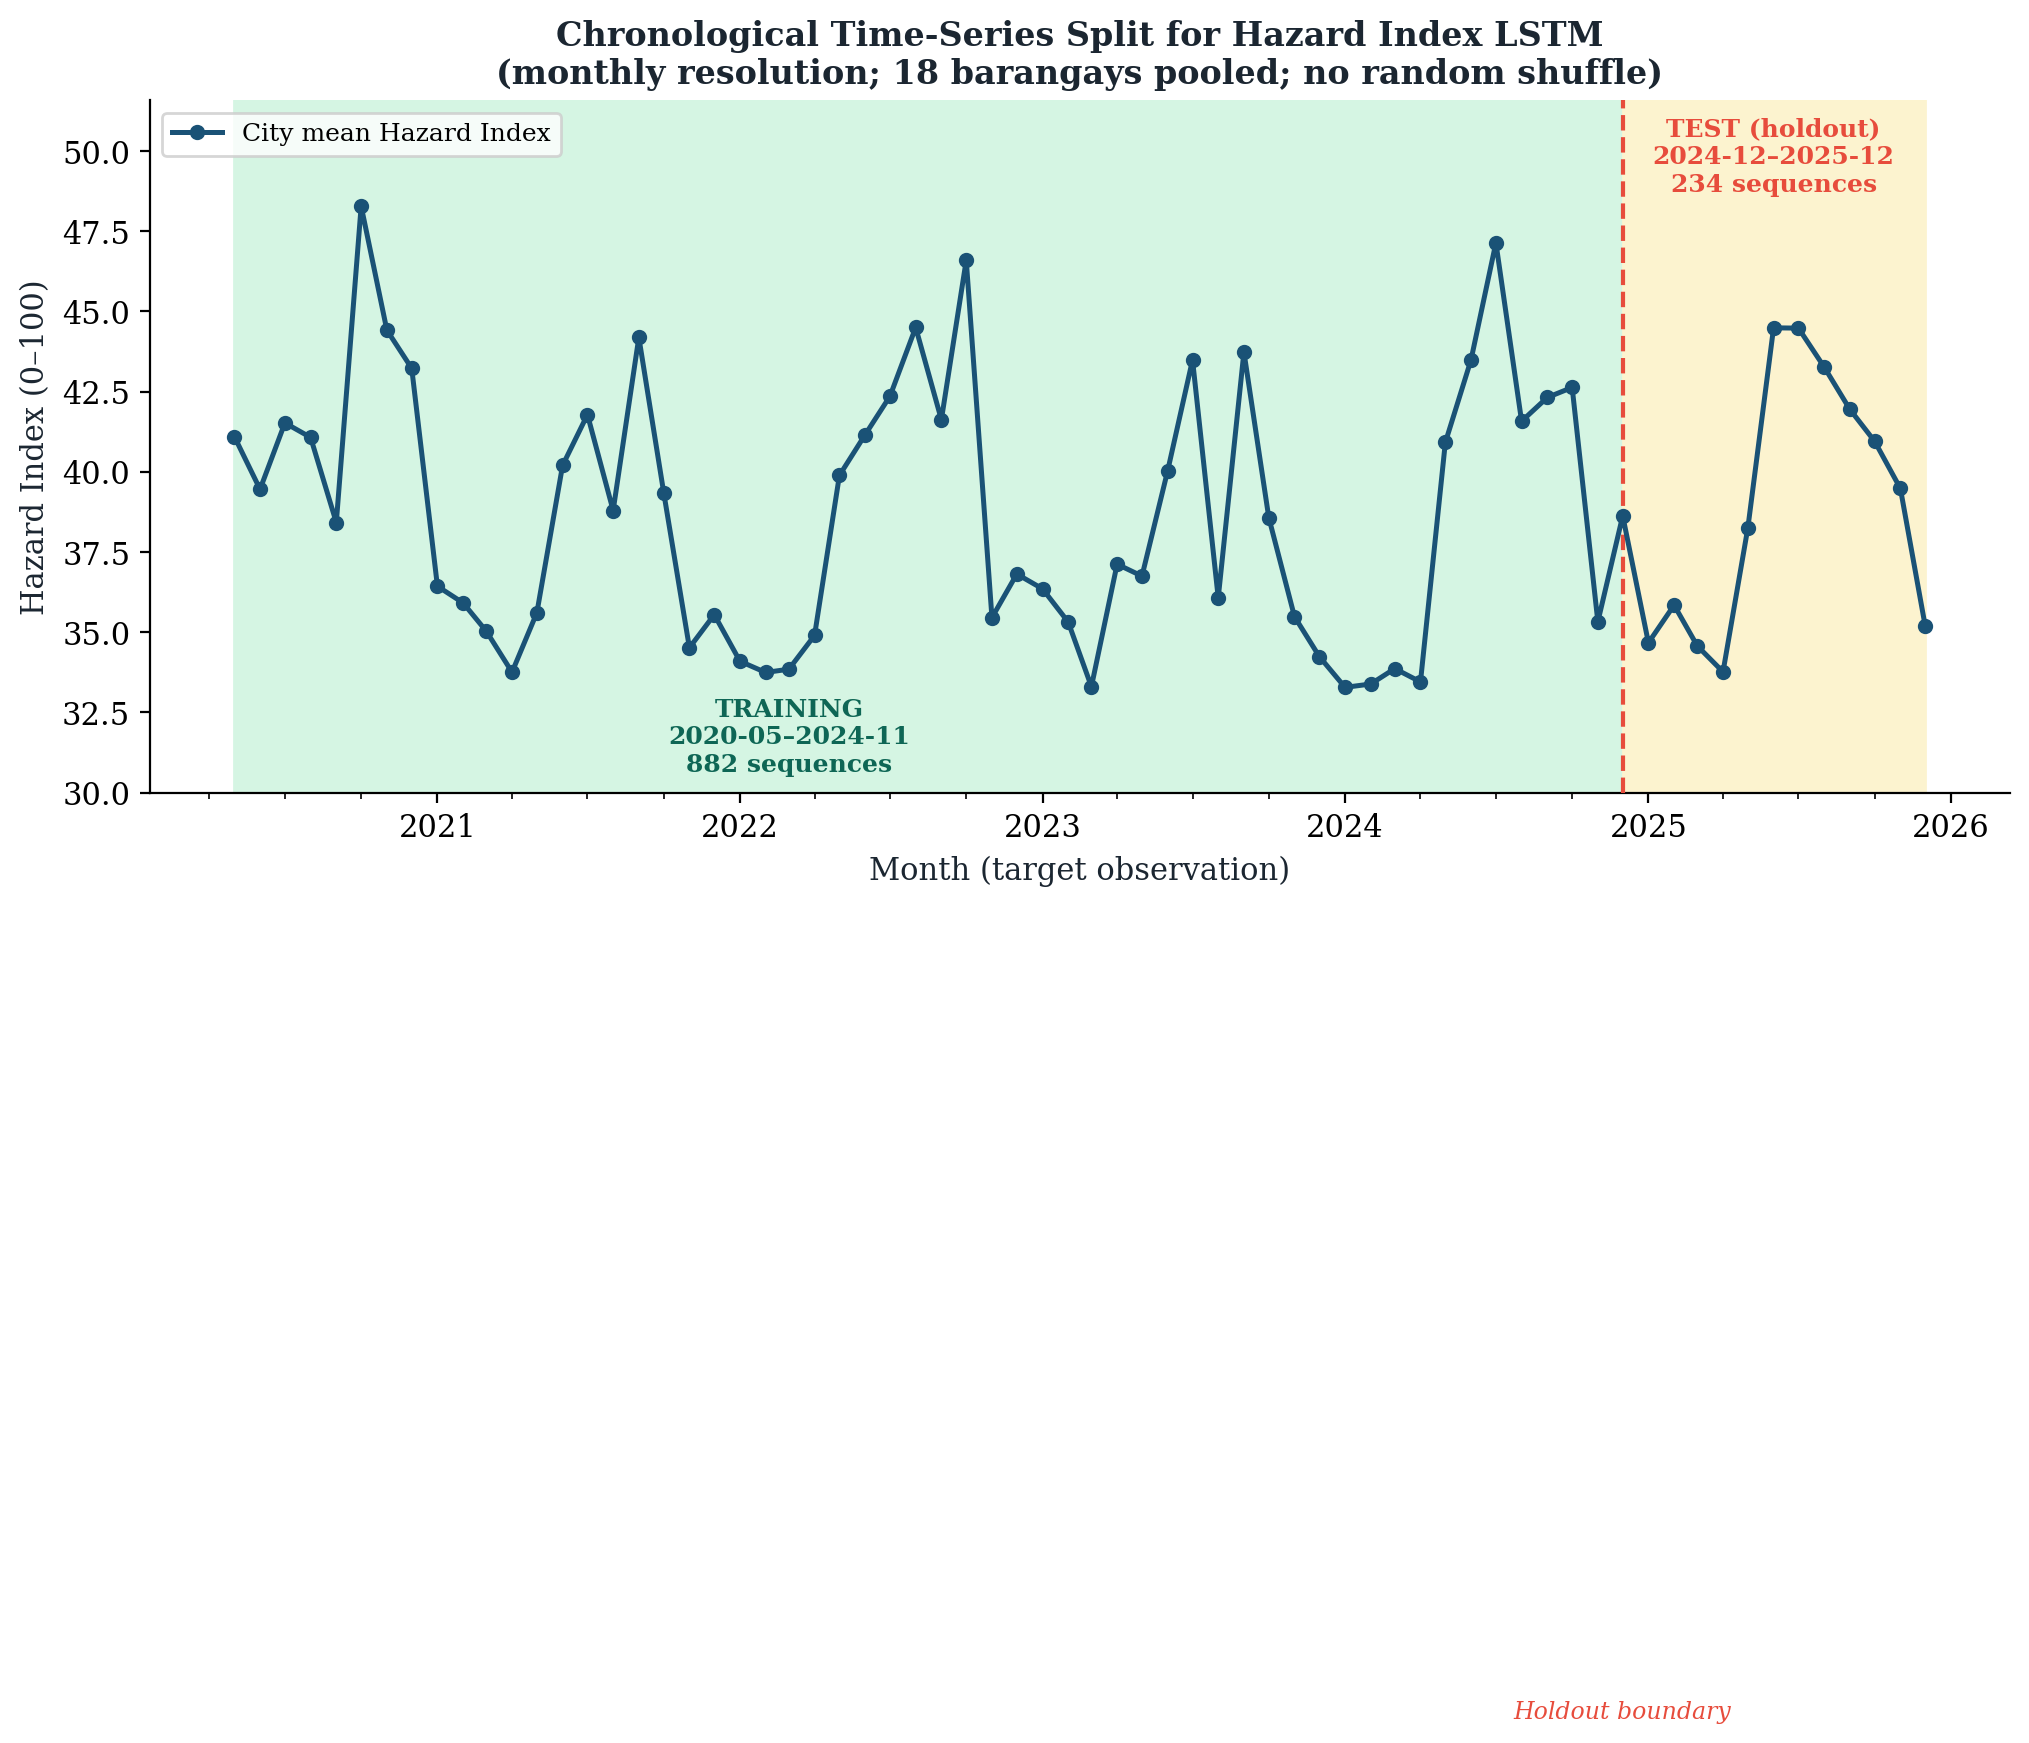


Figure saved → fig_ts_split_hazard_index.png


In [6]:
# Cell 6: Chronological Time-Series Split for Hazard Index LSTM

fig4, ax4 = plt.subplots(figsize=(12, 4.5))
fig4.patch.set_facecolor('white')
ax4.set_facecolor('white')

dates = monthly_hi.index

# ── Shaded regions ──
ax4.axvspan(dates.min(), holdout_date, color=C_TRAIN_BG, zorder=0)
ax4.axvspan(holdout_date, dates.max(), color=C_TEST_BG,  zorder=0)

# ── Holdout boundary ──
ax4.axvline(holdout_date, color=C_BOUNDARY, linewidth=1.5, linestyle='--', zorder=3)
ax4.text(holdout_date, ax4.get_ylim()[1] if ax4.get_ylim()[1] > 0 else monthly_hi.max() * 1.06,
         'Holdout boundary', color=C_BOUNDARY, fontsize=8.5,
         ha='center', va='bottom', fontstyle='italic')

# ── Line plot ──
ax4.plot(dates, monthly_hi.values, color=C_LINE, linewidth=1.8,
         marker='o', markersize=4.5, markerfacecolor=C_LINE,
         markeredgecolor=C_LINE, zorder=5, label='City mean Hazard Index')

# ── Training annotation ──
train_mid_date = dates[len(dates) // 3]
y_lo = monthly_hi.min()
ax4.text(train_mid_date, y_lo - (monthly_hi.max() - y_lo) * 0.02,
         f'TRAINING\n'
         f'{pd.Timestamp(train_start).strftime("%Y-%m")}–{pd.Timestamp(train_end).strftime("%Y-%m")}\n'
         f'{n_train_seq} sequences',
         fontsize=9, fontweight='bold', color='#0e6655',
         ha='center', va='top')

# ── Test annotation ──
test_mid_idx = first_test_target_idx + (len(dates) - first_test_target_idx) // 2
test_mid_date = dates[min(test_mid_idx, len(dates)-1)]
ax4.text(test_mid_date, monthly_hi.max() + (monthly_hi.max() - y_lo) * 0.02,
         f'TEST (holdout)\n'
         f'{pd.Timestamp(test_start).strftime("%Y-%m")}–{pd.Timestamp(test_end).strftime("%Y-%m")}\n'
         f'{n_test_seq} sequences',
         fontsize=9, fontweight='bold', color=C_BOUNDARY,
         ha='center', va='bottom')

# ── Axis formatting ──
ax4.set_xlabel('Month (target observation)', fontsize=11, color=C_TEXT)
ax4.set_ylabel('Hazard Index (0–100)', fontsize=11, color=C_TEXT)
ax4.set_title(
    'Chronological Time-Series Split for Hazard Index LSTM\n'
    f'(monthly resolution; {n_barangays} barangays pooled; no random shuffle)',
    fontsize=12, fontweight='bold', color=C_TEXT)

ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.legend(loc='upper left', fontsize=9, frameon=True,
           facecolor='white', edgecolor='#cccccc')

# ── Adjust y limits for annotation space ──
y_range = monthly_hi.max() - monthly_hi.min()
ax4.set_ylim(monthly_hi.min() - y_range * 0.22, monthly_hi.max() + y_range * 0.22)

plt.tight_layout()
plt.savefig('fig_ts_split_hazard_index.png', bbox_inches='tight', facecolor='white')
plt.show()

print('\nFigure saved → fig_ts_split_hazard_index.png')

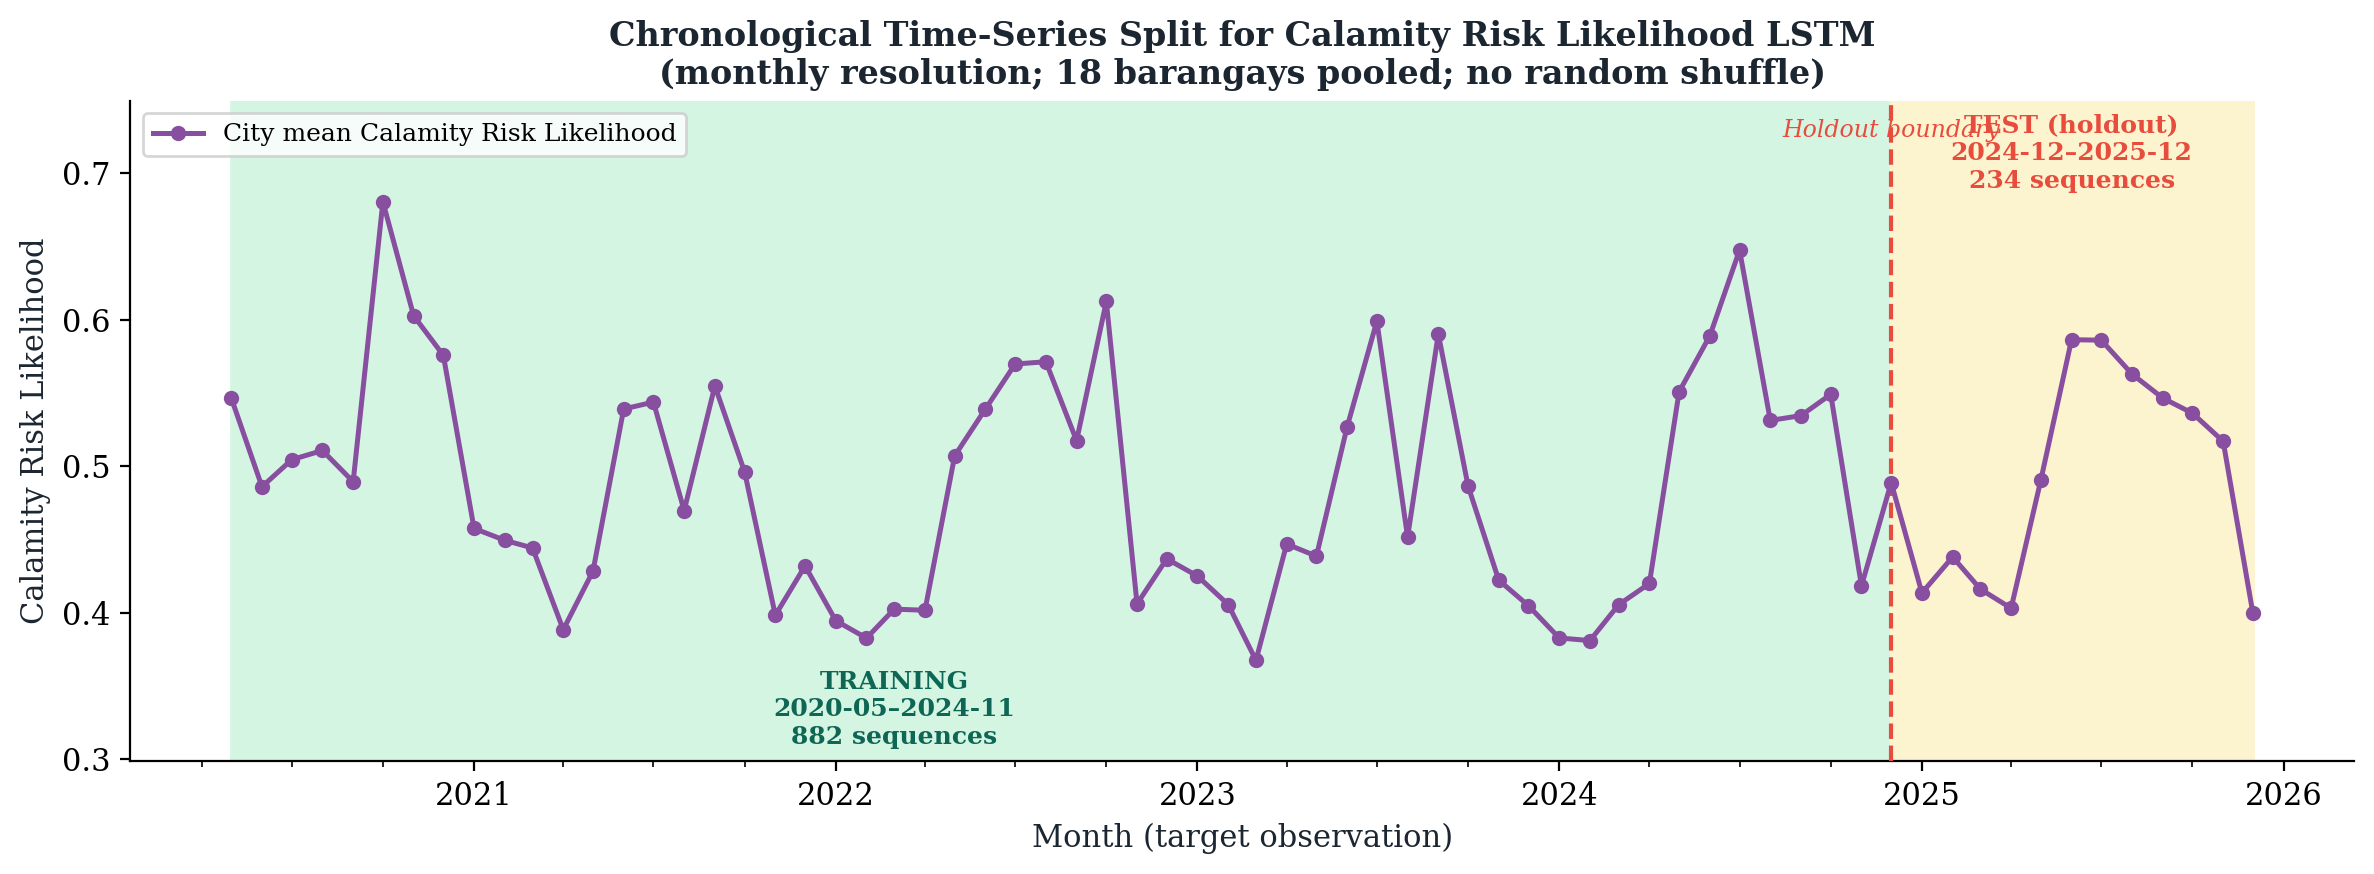


Figure saved → fig_ts_split_calamity_risk.png


In [7]:
# Cell 7: Chronological Time-Series Split for Calamity Risk Likelihood LSTM

fig5, ax5 = plt.subplots(figsize=(12, 4.5))
fig5.patch.set_facecolor('white')
ax5.set_facecolor('white')

dates_crl = monthly_crl.index

# ── Shaded regions ──
ax5.axvspan(dates_crl.min(), holdout_date, color=C_TRAIN_BG, zorder=0)
ax5.axvspan(holdout_date, dates_crl.max(), color=C_TEST_BG,  zorder=0)

# ── Holdout boundary ──
ax5.axvline(holdout_date, color=C_BOUNDARY, linewidth=1.5, linestyle='--', zorder=3)
ax5.text(holdout_date, monthly_crl.max() * 1.06,
         'Holdout boundary', color=C_BOUNDARY, fontsize=8.5,
         ha='center', va='bottom', fontstyle='italic')

# ── Line plot ──
ax5.plot(dates_crl, monthly_crl.values, color='#884ea0', linewidth=1.8,
         marker='o', markersize=4.5, markerfacecolor='#884ea0',
         markeredgecolor='#884ea0', zorder=5,
         label='City mean Calamity Risk Likelihood')

# ── Training annotation ──
train_mid_date_crl = dates_crl[len(dates_crl) // 3]
y_lo_crl = monthly_crl.min()
ax5.text(train_mid_date_crl, y_lo_crl - (monthly_crl.max() - y_lo_crl) * 0.02,
         f'TRAINING\n'
         f'{pd.Timestamp(train_start).strftime("%Y-%m")}–{pd.Timestamp(train_end).strftime("%Y-%m")}\n'
         f'{n_train_seq} sequences',
         fontsize=9, fontweight='bold', color='#0e6655',
         ha='center', va='top')

# ── Test annotation ──
test_mid_date_crl = dates_crl[min(test_mid_idx, len(dates_crl)-1)]
ax5.text(test_mid_date_crl, monthly_crl.max() + (monthly_crl.max() - y_lo_crl) * 0.02,
         f'TEST (holdout)\n'
         f'{pd.Timestamp(test_start).strftime("%Y-%m")}–{pd.Timestamp(test_end).strftime("%Y-%m")}\n'
         f'{n_test_seq} sequences',
         fontsize=9, fontweight='bold', color=C_BOUNDARY,
         ha='center', va='bottom')

# ── Axis formatting ──
ax5.set_xlabel('Month (target observation)', fontsize=11, color=C_TEXT)
ax5.set_ylabel('Calamity Risk Likelihood', fontsize=11, color=C_TEXT)
ax5.set_title(
    'Chronological Time-Series Split for Calamity Risk Likelihood LSTM\n'
    f'(monthly resolution; {n_barangays} barangays pooled; no random shuffle)',
    fontsize=12, fontweight='bold', color=C_TEXT)

ax5.xaxis.set_major_locator(mdates.YearLocator())
ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax5.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))

ax5.spines['top'].set_visible(False)
ax5.spines['right'].set_visible(False)
ax5.legend(loc='upper left', fontsize=9, frameon=True,
           facecolor='white', edgecolor='#cccccc')

# ── Adjust y limits for annotation space ──
y_range_crl = monthly_crl.max() - monthly_crl.min()
ax5.set_ylim(monthly_crl.min() - y_range_crl * 0.22,
             monthly_crl.max() + y_range_crl * 0.22)

plt.tight_layout()
plt.savefig('fig_ts_split_calamity_risk.png', bbox_inches='tight', facecolor='white')
plt.show()

print('\nFigure saved → fig_ts_split_calamity_risk.png')

---
### Defense Talking Points

When presenting these figures, you can explain the deliberate design choices:

1. **Green Index (64/16/20)** — Environmental data (NDVI-based) exhibits relatively smooth seasonal patterns. A dedicated **validation set** was required for hyperparameter tuning (learning rate, number of LSTM units, dropout rate) and early-stopping to prevent overfitting on the slow-changing vegetation signal.

2. **Hazard Index & Calamity Risk Likelihood (80/20)** — Disaster event data (earthquake, typhoon, flood) is inherently sparse and bursty. Maximizing the **historical learning window** (80 %) ensures the LSTM captures enough rare-event occurrences to generalize. A separate validation partition was not necessary because the model architecture mirrors the already-tuned Green Index pipeline.

> This demonstrates **deep, intentional mastery** over your dataset — you tailored the partitioning strategy to the statistical properties of each index rather than applying a single blanket approach.